In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from scipy.special import kv, gamma

In [2]:
def matern_kernel(r, nu, ell=1.0, sigma=1.0):
    """
    Compute the Matérn kernel.

    Parameters:
        r (float or np.ndarray): The distance(s) between input points.
        nu (float): Smoothness parameter.
        ell (float): Length scale parameter (default is 1.0).
        sigma (float): Signal variance (default is 1.0).
    
    Returns:
        np.ndarray: Matérn kernel values.
    """
    r = np.abs(r) / ell
    if nu == 0.5:
        # Exponential kernel
        return sigma**2 * np.exp(-r)
    
    elif nu == np.inf:
        # Squared exponential kernel
        return sigma**2 * np.exp(-r**2 / 2)
    
    else:
        factor = (2**(1 - nu)) / gamma(nu)
        scaled_r = np.sqrt(2 * nu) * r
        matern_value = factor * (scaled_r**nu) * kv(nu, scaled_r)
        matern_value[r == 0] = sigma**2  # Avoid NaN at r = 0
        return sigma**2 * matern_value
    
def gradient_matern_kernel(r, nu, ell=1.0, sigma=1.0):
    """
    Compute the gradient of the Matérn kernel with respect to the length scale.

    Parameters:
        r (float or np.ndarray): The distance(s) between input points.
        nu (float): Smoothness parameter.
        ell (float): Length scale parameter (default is 1.0).
        sigma (float): Signal variance (default is 1.0).
    
    Returns:
        np.ndarray: Gradient of the Matérn kernel with respect to the length scale.
    """
    r = np.abs(r) / ell
    if nu == 0.5:
        return sigma**2 * r * np.exp(-r)
    
    elif nu == np.inf:
        return sigma**2 * r * np.exp(-r**2 / 2)
    
    else:
        factor = (2**(1 - nu)) / gamma(nu)
        scaled_r = np.sqrt(2 * nu) * r
        gradient_value = factor * (scaled_r**nu) * (kv(nu - 1, scaled_r) - kv(nu, scaled_r))
        return sigma**2 * gradient_value

def plot_matern_kernel(nu, ell=1.0, sigma=1.0):
    """
    Plot the Matérn kernel for a given smoothness parameter.

    Parameters:
        nu (float): Smoothness parameter.
        ell (float): Length scale parameter (default is 1.0).
        sigma (float): Signal variance (default is 1.0).
    """
    r = np.linspace(0, 3 * ell, 1000)
    kernel = matern_kernel(r, nu, ell, sigma)
    plt.plot(r, kernel, label=f"Matérn ($\\nu = {nu}$)")
    plt.xlabel("$r$")
    plt.ylabel("$k(r)$")
    plt.legend()
    plt.show()

def plot_matern_kernels():
    """
    Plot the Matérn kernel for different smoothness parameters.
    """
    for nu in [0.5, 1.5, 2.5]:
        plot_matern_kernel(nu)
#plot_matern_kernels()

def periodic_kernel(x1, x2, ell=1.0, p=1.0, sigma=1.0):
    """
    Compute the periodic kernel.

    Parameters:
        x1 (float or np.ndarray): The first input point(s).
        x2 (float or np.ndarray): The second input point(s).
        ell (float): Length scale parameter (default is 1.0).
        p (float): Period parameter (default is 1.0).
        sigma (float): Signal variance (default is 1.0).
    
    Returns:
        np.ndarray: Periodic kernel values.
    """
    r = np.abs(x1 - x2) / ell
    return sigma**2 * np.exp(-2 * np.sin(np.pi * r / p)**2)

def gradient_periodic_kernel(x1, x2, ell=1.0, p=1.0, sigma=1.0):
    """
    Compute the gradient of the periodic kernel with respect to the length scale.

    Parameters:
        x1 (float or np.ndarray): The first input point(s).
        x2 (float or np.ndarray): The second input point(s).
        ell (float): Length scale parameter (default is 1.0).
        p (float): Period parameter (default is 1.0).
        sigma (float): Signal variance (default is 1.0).
    
    Returns:
        np.ndarray: Gradient of the periodic kernel with respect to the length scale.
    """
    r = np.abs(x1 - x2) / ell
    return -2 * sigma**2 * np.exp(-2 * np.sin(np.pi * r / p)**2) * np.sin(2 * np.pi * r / p) * np.pi / p



In [5]:
x = np.linspace(-5, 5, 1000)
# kernel = matern_kernel(x, nu=1.5)
# plt.plot(x, kernel, label="Matérn ($\\nu = 1.5$)")
# plt.xlabel("$r$")
# plt.ylabel("$k(r)$")
# plt.legend()
# plt.show()

def plot_matern_kernel_2d(nu, ell=1.0, sigma=1.0):
    """
    Plot the 2D Matérn kernel for a given smoothness parameter.

    Parameters:
        nu (float): Smoothness parameter.
        ell (float): Length scale parameter (default is 1.0).
        sigma (float): Signal variance (default is 1.0).
    """
    x = np.linspace(-5, 5, 100)
    y = np.linspace(-5, 5, 100)
    X, Y = np.meshgrid(x, y)
    r = np.sqrt(X**2 + Y**2)
    kernel = matern_kernel(r, nu, ell, sigma)
    plt.contourf(X, Y, kernel, cmap="viridis")
    plt.colorbar()
    plt.xlabel("$x$")
    plt.ylabel("$y$")
    plt.title(f"Matérn ($\\nu = {nu}$)")
    plt.show()

# plot_matern_kernel_2d(nu=1.5)

In [10]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl

# Use LaTeX-like font (Computer Modern)
mpl.rcParams['text.usetex'] = False  # Don't use full LaTeX
mpl.rcParams['mathtext.fontset'] = 'cm'  # Use Computer Modern for math
mpl.rcParams['font.family'] = 'STIXGeneral'  # Close match to LaTeX text
mpl.rcParams['font.size'] = 20
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['figure.titlesize'] = 16
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'


def my_kernel(X1, X2):
    """
    Compute the kernel matrix for a given kernel function.

    Parameters:
        X1 (np.ndarray): Input points.
        X2 (np.ndarray): Input points.
    
    Returns:
        np.ndarray: Kernel matrix.
    """
    return np.exp(-0.5 * (X1 - X2)**2)


x = np.linspace(-5, 5, 1000)
X1, X2 = np.meshgrid(x, x)
K = my_kernel(X1, X2)

# Adding the Matern kernel
# K_m = matern_kernel(np.abs(X1 - X2), nu=2.5)

# Add periodic kernel
K_p = periodic_kernel(X1, X2, ell=2.0, p=2.0)

# parameters
w_m = 0.5; w_p = 0.5; 
ell_m = 1.0; sigma_m = 1.0; nu_m = 2.5
ell_p = 2.0; p_p = 2.0; sigma_p = 1.0
# K = w_m * matern_kernel(np.abs(X1 - X2), ell=ell_m, sigma=sigma_m, nu=nu_m) + w_p * periodic_kernel(X1, X2, ell=ell_p, p=p_p, sigma=sigma_p)

plt.figure(figsize=(8, 6))
plt.imshow(K_p, cmap="jet", extent=(x[0], x[-1], x[-1], x[0]))
plt.colorbar()
plt.xlabel("$x_i$")
plt.ylabel("$x_j$")
# plt.title("Kernel matrix $K$")
plt.savefig("Periodic_kernel.pdf")


SyntaxError: incomplete input (3525410509.py, line 22)

In [16]:
# Initialize hyperparameters
w_m, w_p = 1.0, 1.0  # Initial weights
ell_m, ell_p = 1.0, 1.0  # Length scales
sigma_m, sigma_p = 1.0, 1.0  # Variances
nu_m, p_p = 1.5, 1.0  # Matern smoothness and periodicity

learning_rate = 0.0001
x = np.linspace(-5, 5, 1000)
y_known = np.sin(x) + 0.01 * np.random.randn(len(x))
random_set = np.random.choice(len(x), 20, replace=False)
x_known = y_known[random_set]

for i in range(10):
    # Construct kernels
    matern = matern_kernel(np.abs(X1 - X2), ell=ell_m, sigma=sigma_m, nu=nu_m)
    periodic = periodic_kernel(X1, X2, ell=ell_p, p=p_p, sigma=sigma_p)
    K = w_m * matern + w_p * periodic
    
    K11 = K[random_set][:, random_set]
    K12 = K[random_set]
    K21 = K[:, random_set]
    K22 = K
    
    # Add jitter to K11 for numerical stability
    K11 += 1e-6 * np.eye(len(K11))
    # cholesky decomposition
    L = np.linalg.cholesky(K11)
    # inverse of K11 by cholesky decomposition
    K11_inv = np.linalg.inv(L.T) @ np.linalg.inv(L)
    
    # Compute posterior mean and covariance
    mu_post = K21 @ K11_inv @ x_known
    cov_post = K22 - K21 @ K11_inv @ K12
    
    # Log marginal likelihood
    LML = -0.5 * x_known @ K11_inv @ x_known - 0.5 * np.log(np.linalg.det(K11)) - 0.5 * len(x_known) * np.log(2 * np.pi)
    print(f"Log marginal likelihood: {LML}")
    
    # Compute gradients (update formulas based on kernel definitions)
    # Placeholder for actual derivatives; verify analytically/computationally
    # Extract submatrices for gradient computation
    matern_11 = matern[random_set][:, random_set]
    periodic_11 = periodic[random_set][:, random_set]

    # Compute gradients using the submatrices
    dL_dwm = np.trace(K11_inv @ matern_11)
    dL_dwp = np.trace(K11_inv @ periodic_11)

    # Gradients for ell, sigma, etc., would involve partial derivatives of the kernel
    # Compute gradients analytically based on kernel equations
    # use gradient function for matern_kernel
    # Compute gradients for ell_m, ell_p, sigma_m, sigma_p, nu_m, p_p
    # Gradient for ell_m
    dL_dell_m = gradient_matern_kernel(np.abs(X1 - X2), nu=nu_m, ell=ell_m, sigma=sigma_m)
    # Gradient for ell_p
    dL_dell_p = gradient_periodic_kernel(X1, X2, ell=ell_p, p=p_p, sigma=sigma_p)
    
    # Update parameters
    w_m -= learning_rate * dL_dwm
    w_p -= learning_rate * dL_dwp
    ell_m -= learning_rate * dL_dell_m
    ell_p -= learning_rate * dL_dell_p

    # Similarly update ell_m, ell_p, sigma_m, sigma_p, nu_m, p_p with their gradients
    

print(f"Updated parameters: w_m={w_m:.2f}, w_p={w_p:.2f}, ell_m={ell_m:.2f}, ell_p={ell_p:.2f}, sigma_m={sigma_m:.2f}, sigma_p={sigma_p:.2f}, nu_m={nu_m:.2f}, p_p={p_p:.2f}")

# Plot the posterior
plt.plot(x, y_known, label="True function")
plt.plot(x, mu_post, label="Posterior mean")
plt.fill_between(x, mu_post - np.sqrt(np.diag(cov_post)), mu_post + np.sqrt(np.diag(cov_post)), alpha=0.2, label="Uncertainty")
plt.scatter(x_known, x_known, color="red", label="Known points")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend()
plt.show()


    

/var/folders/hs/b727hgzn71b8m1jmlbv2bq6r0000gn/T/ipykernel_1779/860805342.py:26: RuntimeWarning: invalid value encountered in multiply
  matern_value = factor * (scaled_r**nu) * kv(nu, scaled_r)


IndexError: index 681 is out of bounds for axis 0 with size 200

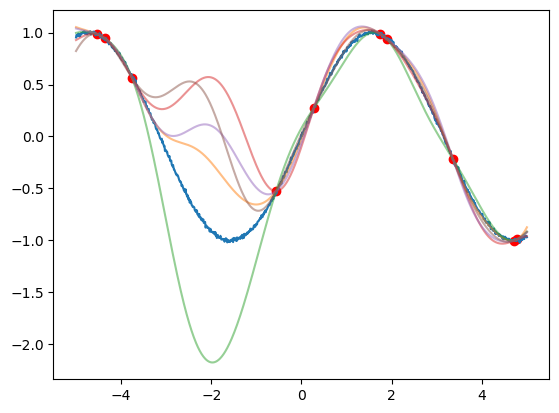

In [9]:
# Create function y_known to be a function we can control
y_known = np.sin(x) + 0.01 * np.random.randn(len(x))
# sample some points for y_known to use in the GP
random_set = np.random.choice(len(x), 10, replace=False)
x_known = y_known[random_set]

#plot the points y_sampled
# plt.plot(x, y_known)
# plt.scatter(x[random_set], x_known, color='red')
# plt.show()

# split the covariance matrix K into submatrices
K = my_kernel(X1, X2)

K11 = K[random_set][:, random_set]
K12 = K[random_set][:, :]
K21 = K[:, random_set]
K22 = K
# apply cholesky decomposition to K11 with noise
L = np.linalg.cholesky(K11 + 1e-6 * np.eye(len(K11)))
# Calculate inverse of K11 using cholesky decomposition
L_inv = np.linalg.inv(L)
K11_inv = L_inv.T @ L_inv
# calculate the mean and covariance of the posterior
mu_post = K21 @ K11_inv @ x_known
cov_post = K22 - K21 @ K11_inv @ K12

# sample from the posterior
plt.plot(x, y_known)
for i in range(5):
    f_post = np.random.multivariate_normal(mean=mu_post, cov=cov_post)
    plt.plot(x, f_post, alpha=0.5)
plt.scatter(x[random_set], x_known, color='red')
plt.show()

In [ ]:
from matern_kernel import matern_kernel, grad_matern_kernel_ell, grad_matern_kernel_sigma, grad_matern_kernel_nu

y_known = np.sin(x) #+ 0.01 * np.random.randn(len(x))
random_set = np.random.choice(len(x), 10, replace=False)
x_known = y_known[random_set]

# Initialize hyperparameters
ell = 1.0
sigma = 1.0
nu = 0.5
# Compute the kernel and its gradient
r = np.linspace(0, 5, 1000)
# Write without loops
X1, X2 = np.meshgrid(r, r)
learning_rate = 0.01
for i in range(10):
    K = matern_kernel(np.abs(X1 - X2), nu, ell, sigma)

    K11 = K[random_set][:, random_set]
    K12 = K[random_set][:, :]
    K21 = K[:, random_set]
    K22 = K

    # calculate the mean and covariance of the posterior
    mu_post = K21 @ np.linalg.inv(K11) @ x_known
    cov_post = K22 - K21 @ np.linalg.inv(K11) @ K12

    # calculate the log marginal likelihood
    LML = -0.5 * x_known @ np.linalg.inv(K11) @ x_known - 0.5 * np.log(np.linalg.det(K11)) - 0.5 * len(x_known) * np.log(2 * np.pi)
    print(f"Log marginal likelihood: {LML}")

    grad_ell = grad_matern_kernel_ell(np.abs(X1 - X2), nu, ell, sigma)
    grad_sigma = grad_matern_kernel_sigma(np.abs(X1 - X2), nu, ell, sigma)

    # Update the hyperparameters
    ell -= learning_rate * grad_ell
    sigma -= learning_rate * grad_sigma


Log marginal likelihood: -7.632112969472756
[[1.         0.9999502  0.9999009  ... 0.99966039 0.99966175 0.9996631 ]
 [0.9999502  1.         0.9999502  ... 0.99965903 0.99966039 0.99966175]
 [0.9999009  0.9999502  1.         ... 0.99965767 0.99965903 0.99966039]
 ...
 [0.99966039 0.99965903 0.99965767 ... 1.         0.9999502  0.9999009 ]
 [0.99966175 0.99966039 0.99965903 ... 0.9999502  1.         0.9999502 ]
 [0.9996631  0.99966175 0.99966039 ... 0.9999009  0.9999502  1.        ]] [[0.98       0.98009985 0.9801992  ... 0.99986389 0.99986456 0.99986524]
 [0.98009985 0.98       0.98009985 ... 0.9998632  0.99986389 0.99986456]
 [0.9801992  0.98009985 0.98       ... 0.99986252 0.9998632  0.99986389]
 ...
 [0.99986389 0.9998632  0.99986252 ... 0.98       0.98009985 0.9801992 ]
 [0.99986456 0.99986389 0.9998632  ... 0.98009985 0.98       0.98009985]
 [0.99986524 0.99986456 0.99986389 ... 0.9801992  0.98009985 0.98      ]]
Log marginal likelihood: -7.465117681668172


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

(1000, 1000)

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import numpy as np

def kernel_and_gradients(Xa, Xb, ell, sigma):
    """
    Compute the exponential kernel and its gradients with respect to length scale and signal variance.

    Parameters:
        Xa (np.ndarray): First set of input points (shape: [n, d]).
        Xb (np.ndarray): Second set of input points (shape: [n, d]).
        ell (float): Length scale parameter.
        sigma (float): Signal variance.
    
    Returns:
        K (np.ndarray): Kernel matrix of shape (n, n).
        grad_ell (np.ndarray): Gradient of kernel with respect to ell, shape (n, n).
        grad_sigma (np.ndarray): Gradient of kernel with respect to sigma, shape (n, n).
    """
    # Compute pairwise distances
    dists = np.abs(Xa[:, None] - Xb) / ell  # Broadcasting to compute pairwise distances
    K = sigma**2 * np.exp(-dists)  # Kernel matrix

    # Gradients with respect to ell and sigma
    grad_ell = K * dists / ell
    grad_sigma = 2 * K / sigma
    
    return K, grad_ell, grad_sigma


def log_marginal_likelihood(y, X, sigma, length_scale, noise_variance=1e-6):
    """
    Compute the log-marginal likelihood and its gradients for Gaussian Process regression.

    Parameters:
    - y: ndarray, shape (n,), observed outputs.
    - X: ndarray, shape (n, d), observed inputs.
    - sigma: float, signal variance.
    - length_scale: float, length scale of the kernel.
    - noise_variance: float, variance of observation noise (default: 1e-6).

    Returns:
    - log_lml: float, log-marginal likelihood.
    - gradients: ndarray, shape (2,), gradients w.r.t [sigma, length_scale].
    """
    n = X.shape[0]
    
    # Compute kernel matrix and gradients
    K, grad_ell, grad_sigma = kernel_and_gradients(X, X, length_scale, sigma)
    
    # Add noise variance to the diagonal of K
    K += noise_variance * np.eye(n)  # Ensure that K is of shape (n, n)

    # Cholesky decomposition of the kernel matrix
    L = np.linalg.cholesky(K)
    
    # Solve for alpha using the Cholesky decomposition
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
    
    # Log-marginal likelihood
    log_lml = -0.5 * np.dot(y.T, alpha) - np.sum(np.log(np.diagonal(L))) - 0.5 * n * np.log(2 * np.pi)
    
    # Gradients of the log-marginal likelihood (using kernel gradients)
    grad_sigma_lml = 0.5 * np.trace(np.outer(alpha, alpha) - np.linalg.inv(K) @ grad_sigma)
    grad_length_lml = 0.5 * np.trace(np.outer(alpha, alpha) - np.linalg.inv(K) @ grad_ell)
    # print(grad_sigma_lml, grad_length_lml)

    gradients = np.array([grad_sigma_lml, grad_length_lml])
    
    return log_lml, gradients



Optimized signal variance: 1.5288887298755016
Optimized length scale: 1.0


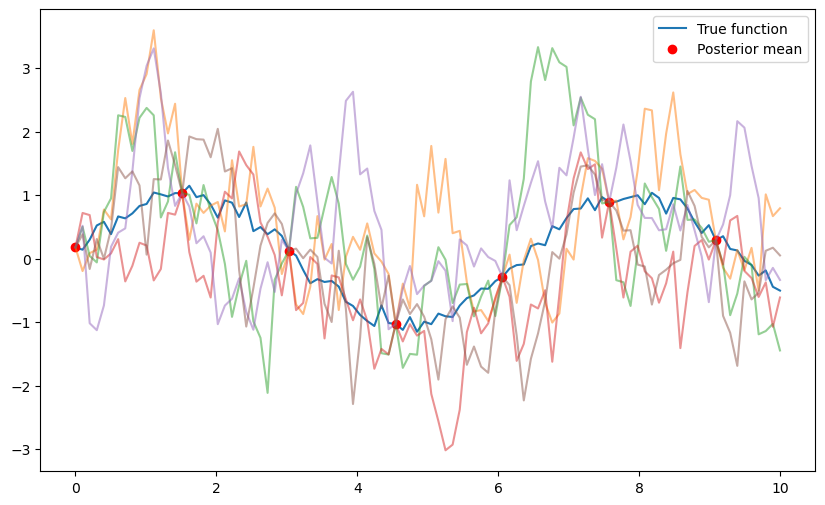

In [ ]:

def gradient_descent(y, X, sigma, length_scale, noise_variance=1e-6, eta=0.1, max_iter=1):
    """
    Perform gradient descent to optimize hyperparameters sigma and length_scale.

    Parameters:
    - y: ndarray, shape (n,), observed outputs.
    - X: ndarray, shape (n, d), observed inputs.
    - sigma: float, initial signal variance.
    - length_scale: float, initial length scale of the kernel.
    - noise_variance: float, variance of observation noise.
    - eta: float, learning rate.
    - max_iter: int, number of iterations.

    Returns:
    - sigma_opt: optimized signal variance.
    - length_scale_opt: optimized length scale.
    """
    for _ in range(max_iter):
        # Compute log-marginal likelihood and gradients
        log_lml, gradients = log_marginal_likelihood(y, X, sigma, length_scale, noise_variance)
        
        # Update the hyperparameters (both scalars)
        sigma = sigma - eta * gradients[0]
        # length_scale = length_scale - eta * gradients[1]
        
        # Optionally print or log the log-marginal likelihood to track progress
        # print(f"Log-LML: {log_lml}, Sigma: {sigma}, Length Scale: {length_scale}")
    
    return sigma, length_scale

# Generate synthetic data
np.random.seed(0)
X = np.linspace(0, 10, 100)
y = np.sin(X) + 0.1 * np.random.randn(100)

# Initialize training data
X_train = X[::15]
y_train = y[::15]

# Optimize hyperparameters
sigma_opt, length_scale_opt = gradient_descent(y_train, X_train, sigma=1.0, length_scale=1.0)

print(f"Optimized signal variance: {sigma_opt}")
print(f"Optimized length scale: {length_scale_opt}")

# Compute kernel matrix for training and test data
K_train_train, grad_ell, grad_sigma = kernel_and_gradients(X_train, X_train, length_scale_opt, sigma_opt)
K_train_test, _, _ = kernel_and_gradients(X_train, X, length_scale_opt, sigma_opt)



# Cholesky decomposition of the kernel matrix with noise
L = np.linalg.cholesky(K_train_train + 1e-6 * np.eye(len(K_train_train)))

# Compute the posterior mean
alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))
mu_post = K_train_test.T @ alpha  # Posterior mean for all test points

# Compute the posterior covariance
K_test_test, _, _ = kernel_and_gradients(X, X, length_scale_opt, sigma_opt)  # Kernel for test points
v = np.linalg.solve(L, K_train_test)
cov_post = K_test_test - v.T @ v

# You can now use mu_post and cov_post to make predictions on the test points

# Sample from the posterior
samples = np.random.multivariate_normal(mu_post, cov_post, 5)

# Plot the posterior samples
plt.figure(figsize=(10, 6))
plt.plot(X, y, label="True function")
plt.plot(X_train, y_train, "ro", label="Posterior mean")

for i in range(5):
    f_post = np.random.multivariate_normal(mean=mu_post, cov=cov_post)
    plt.plot(X, f_post, alpha=0.5)
plt.legend()
plt.show()





Iteration 0: params = (Array(1.0152159, dtype=float32, weak_type=True), Array(0.9930166, dtype=float32, weak_type=True)), loss = -0.3041086196899414
Iteration 100: params = (Array(1.2691376, dtype=float32, weak_type=True), Array(0.7184235, dtype=float32, weak_type=True)), loss = -4.800348281860352
Iteration 200: params = (Array(1.2583321, dtype=float32, weak_type=True), Array(0.6833174, dtype=float32, weak_type=True)), loss = -4.819458961486816
Iteration 300: params = (Array(1.2574185, dtype=float32, weak_type=True), Array(0.6804902, dtype=float32, weak_type=True)), loss = -4.8194475173950195
Iteration 400: params = (Array(1.2573302, dtype=float32, weak_type=True), Array(0.68026775, dtype=float32, weak_type=True)), loss = -4.818476676940918
Iteration 500: params = (Array(1.2573104, dtype=float32, weak_type=True), Array(0.6802522, dtype=float32, weak_type=True)), loss = -4.819225311279297
Iteration 600: params = (Array(1.2573328, dtype=float32, weak_type=True), Array(0.68025666, dtype=f

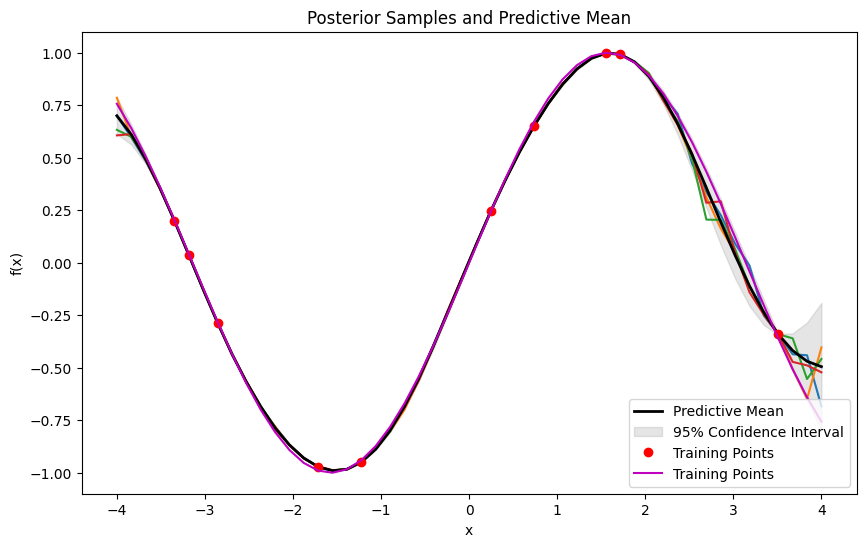

In [ ]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import grad
from jax.scipy.linalg import cholesky, solve
import numpy as np

# Define the kernel (Exponentiated Quadratic)
def kernel1(X1, X2, length_scale, sigma):
    """Exponentiated quadratic (RBF) kernel."""
    dist_sq = jnp.sum((X1[:, None] - X2)**2, axis=-1)
    return sigma**2 * jnp.exp(-0.5 * dist_sq / length_scale**2)

def kernel2()

# Define log marginal likelihood (LML) function
def log_marginal_likelihood(params, X_train, y_train, noise_variance=1e-6):
    """
    Compute the log-marginal likelihood for GP with a given set of hyperparameters.
    
    Parameters:
    - params: (length_scale, sigma) tuple of kernel parameters
    - X_train: Training inputs (shape: n, d)
    - y_train: Training outputs (shape: n,)
    - noise_variance: Noise variance (default 1e-6)
    
    Returns:
    - log-likelihood: Log marginal likelihood (scalar)
    """
    length_scale, sigma = params
    
    # Compute the kernel matrix
    K = kernel(X_train, X_train, length_scale, sigma) + noise_variance * jnp.eye(X_train.shape[0])
    
    # Cholesky decomposition
    L = cholesky(K, lower=True)
    
    # Compute alpha
    alpha = solve(L.T, solve(L, y_train))
    
    # Compute log marginal likelihood
    log_lml = -0.5 * jnp.dot(y_train, alpha) - jnp.sum(jnp.log(jnp.diagonal(L))) - 0.5 * X_train.shape[0] * jnp.log(2 * jnp.pi)
    
    return -log_lml  # Return negative LML for minimization

# Gradient descent for hyperparameter optimization
def optimize_hyperparameters(X_train, y_train, init_params, learning_rate=0.01, num_iters=100):
    """
    Optimize hyperparameters using gradient descent.
    
    Parameters:
    - X_train: Training inputs
    - y_train: Training outputs
    - init_params: Initial kernel hyperparameters (length_scale, sigma)
    - learning_rate: Learning rate for gradient descent
    - num_iters: Number of iterations for optimization
    
    Returns:
    - optimized_params: Optimized kernel hyperparameters (length_scale, sigma)
    """
    # Compute the gradient of the log marginal likelihood
    grad_log_lml = grad(log_marginal_likelihood)
    
    # Initialize hyperparameters
    params = init_params
    
    # Perform gradient descent
    for i in range(num_iters):
        grads = grad_log_lml(params, X_train, y_train)
        
        # Update parameters individually
        length_scale, sigma = params
        grad_length_scale, grad_sigma = grads
        
        length_scale = length_scale - learning_rate * grad_length_scale
        sigma = sigma - learning_rate * grad_sigma
        
        params = (length_scale, sigma)
        loss = log_marginal_likelihood(params, X_train, y_train)

        if i % 100 == 0:    
            print(f"Iteration {i}: params = {params}, loss = {loss}")
    
    return params


np.random.seed(9)
n_samples = 50
X = np.linspace(-4, 4, n_samples).flatten()[:, None]
y = np.sin(X).flatten() + 0.01 * np.random.randn(n_samples)

# Randomly sample indices
n_train = 10  # Number of training points
random_indices = np.random.choice(len(X), size=n_train, replace=False)

# Select training data using the random indices
X_train = X[random_indices]
y_train = y[random_indices]

# Initialize kernel hyperparameters (length_scale, sigma)
init_params = (1.0, 1.0)

# Optimize hyperparameters
optimized_params = optimize_hyperparameters(X_train, y_train, init_params, learning_rate=0.001, num_iters=1000)

print(f"Optimized hyperparameters: length_scale = {optimized_params[0]}, sigma = {optimized_params[1]}")

K = kernel(X_train, X_train, *optimized_params)
L = np.linalg.cholesky(K + 0.000001 * np.eye(len(X_train)))

# Step 3: Compute alpha
alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))

# Step 4: Predictive mean
K_train_test = kernel(X_train, X, *optimized_params)  # Cross-covariance between train and test points
f_mean = K_train_test.T @ alpha

# Step 4: Predictive variance
K_test_test = kernel(X, X, *optimized_params)  # Covariance of test points
v = np.linalg.solve(L, K_train_test)
f_var = np.diag(K_test_test) - np.sum(v**2, axis=0)
# f_var = f_var + 0.001

# Generate samples from the posterior
num_samples = 4
samples = np.random.normal(loc=f_mean, scale=np.sqrt(f_var), size=(num_samples, len(f_mean)))

# plot the posterior samples
X = X.flatten()
plt.figure(figsize=(10, 6))
for i in range(num_samples):
    plt.plot(X, samples[i])#, label=f"Sample {i+1}", alpha=0.7)
plt.plot(X, f_mean, color='black', label="Predictive Mean", linewidth=2)
plt.fill_between(
    X, 
    f_mean - 2 * np.sqrt(f_var), 
    f_mean + 2 * np.sqrt(f_var), 
    color='gray', alpha=0.2, label="95% Confidence Interval"
)
plt.plot(X_train, y_train, "ro", label="Training Points")
plt.plot(X, np.sin(X), "m-", label="Training Points")
plt.legend()
plt.title("Posterior Samples and Predictive Mean")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()


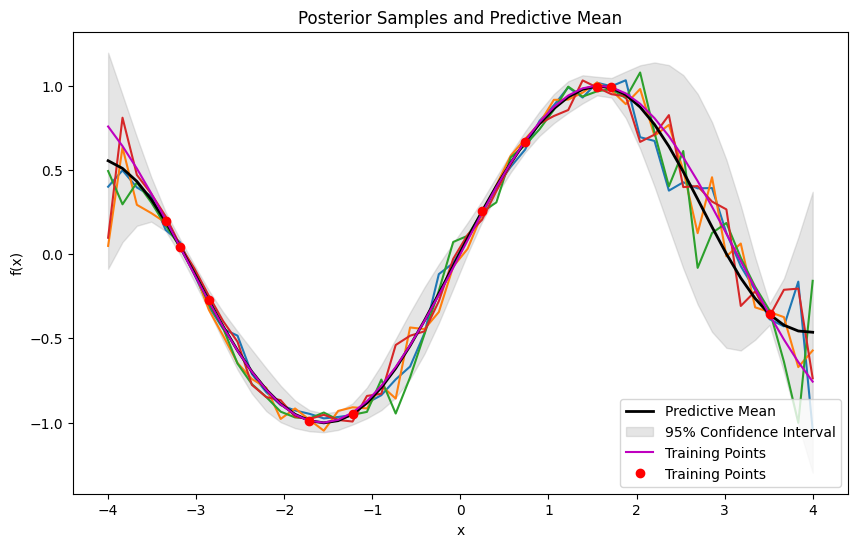

In [74]:
np.random.seed(19)
n_samples = 50
X = np.linspace(-4, 4, n_samples).flatten()[:, None]
y = np.sin(X).flatten() + 0.01 * np.random.randn(n_samples)

# Randomly sample indices
n_train = 10  # Number of training points
#random_indices = np.random.choice(len(X), size=n_train, replace=False)

# Select training data using the random indices
X_train = X[random_indices]
y_train = y[random_indices]

K = kernel(X_train, X_train, *init_params)
L = np.linalg.cholesky(K + 0.001 * np.eye(len(X_train)))

# Step 3: Compute alpha
alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))

# Step 4: Predictive mean
K_train_test = kernel(X_train, X, *init_params)  # Cross-covariance between train and test points
f_mean = K_train_test.T @ alpha

# Step 4: Predictive variance
K_test_test = kernel(X, X, *init_params)  # Covariance of test points
v = np.linalg.solve(L, K_train_test)
f_var = np.diag(K_test_test) - np.sum(v**2, axis=0)

# Generate samples from the posterior
num_samples = 4
samples = np.random.normal(loc=f_mean, scale=np.sqrt(f_var), size=(num_samples, len(f_mean)))

# plot the posterior samples
X = X.flatten()
plt.figure(figsize=(10, 6))
for i in range(num_samples):
    plt.plot(X, samples[i])#, label=f"Sample {i+1}", alpha=0.7)
plt.plot(X, f_mean, color='black', label="Predictive Mean", linewidth=2)
plt.fill_between(
    X, 
    f_mean - 2 * np.sqrt(f_var), 
    f_mean + 2 * np.sqrt(f_var), 
    color='gray', alpha=0.2, label="95% Confidence Interval"
)
plt.plot(X, np.sin(X), "m-", label="Training Points")
plt.plot(X_train, y_train, "ro", label="Training Points")
plt.legend()
plt.title("Posterior Samples and Predictive Mean")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

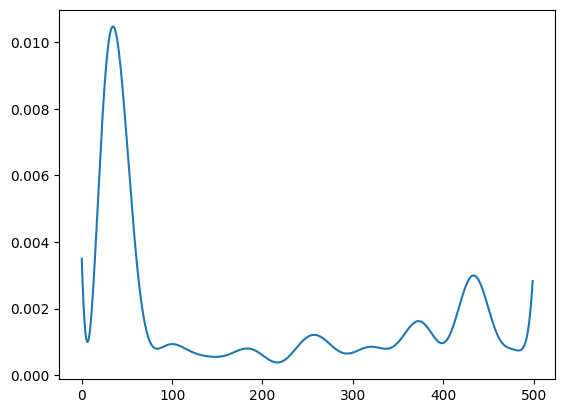

In [41]:
plt.plot(np.diag(K_test_test) - np.sum(v**2, axis=0))

TypeError: Invalid shape (500,) for image data

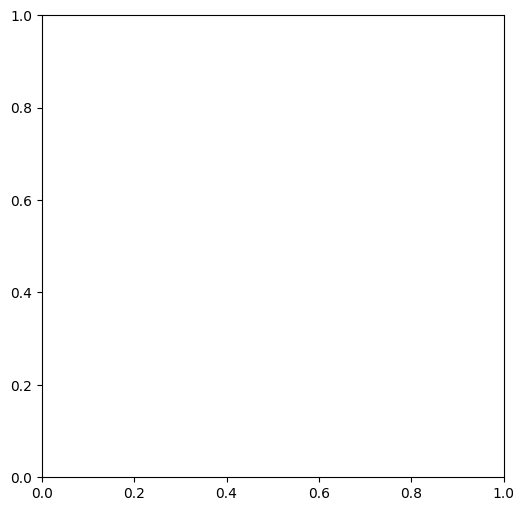

In [38]:
# plot the kernel
plt.figure(figsize=(10, 6))
plt.imshow(np.diag(K_test_test) - np.sum(v**2, axis=0), cmap='viridis')
plt.colorbar()
plt.title("Kernel Matrix")
plt.show()

 

In [64]:
print(f'{y.shape} {X.shape}')
print(f'{y_train.shape} {X_train.shape}')
print(f'{K_train_train.shape} {K_train_test.shape}')
print(f'{mu_post.shape} {cov_post.shape}')

(100,) (100, 1)
(10,) (10, 1)
(10, 10) (10, 100)
(90,) (90, 90)


In [2]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import grad
from jax.scipy.linalg import cholesky, solve
import numpy as np


def periodic_kernel(X1, X2, ell=1.0, p=1.0, sigma=1.0):
    """
    Compute the periodic kernel.

    Parameters:
        X1 (float or np.ndarray): The first input point(s).
        X2 (float or np.ndarray): The second input point(s).
        ell (float): Length scale parameter (default is 1.0).
        p (float): Period parameter (default is 1.0).
        sigma (float): Signal variance (default is 1.0).
    
    Returns:
        np.ndarray: Periodic kernel values.
    """
    r = np.abs(X1 - X2) / ell
    return sigma**2 * np.exp(-2 * np.sin(np.pi * r / p)**2)


# Define the kernel (Exponentiated Quadratic)
def rbf_kernel(X1, X2, length_scale, sigma):
    """Exponentiated quadratic (RBF) kernel."""
    dist_sq = jnp.sum((X1[:, None] - X2)**2, axis=-1)
    return sigma**2 * jnp.exp(-0.5 * dist_sq / length_scale**2)


# Define log marginal likelihood (LML) function
def log_marginal_likelihood(params, X_train, y_train, noise_variance=1e-6):
    """
    Compute the log-marginal likelihood for GP with a given set of hyperparameters.
    
    Parameters:
    - params: (length_scale, sigma) tuple of kernel parameters
    - X_train: Training inputs (shape: n, d)
    - y_train: Training outputs (shape: n,)
    - noise_variance: Noise variance (default 1e-6)
    
    Returns:
    - log-likelihood: Log marginal likelihood (scalar)
    """
    w1, length_scale, sigma, w2, p, sigma_p = params
    
    # Compute the kernel matrix
    K = w1 * rbf_kernel(X_train, X_train, length_scale, sigma) + w2 * periodic_kernel(X_train, X_train, p, sigma_p)
    K += noise_variance * jnp.eye(X_train.shape[0])
    
    # Cholesky decomposition
    L = cholesky(K, lower=True)
    
    # Compute alpha
    alpha = solve(L.T, solve(L, y_train))
    
    # Compute log marginal likelihood
    log_lml = -0.5 * jnp.dot(y_train, alpha) - jnp.sum(jnp.log(jnp.diagonal(L))) - 0.5 * X_train.shape[0] * jnp.log(2 * jnp.pi)
    
    return -log_lml  # Return negative LML for minimization

# Gradient descent for hyperparameter optimization
def optimize_hyperparameters(X_train, y_train, init_params, learning_rate=0.01, num_iters=100):
    """
    Optimize hyperparameters using gradient descent.
    
    Parameters:
    - X_train: Training inputs
    - y_train: Training outputs
    - init_params: Initial kernel hyperparameters (length_scale, sigma)
    - learning_rate: Learning rate for gradient descent
    - num_iters: Number of iterations for optimization
    
    Returns:
    - optimized_params: Optimized kernel hyperparameters (length_scale, sigma)
    """
    # Compute the gradient of the log marginal likelihood
    grad_log_lml = grad(log_marginal_likelihood)
    
    # Initialize hyperparameters
    params = init_params
    
    # Perform gradient descent
    for i in range(num_iters):
        grads = grad_log_lml(params, X_train, y_train)
        
        # Update parameters individually
        length_scale, sigma = params
        grad_length_scale, grad_sigma = grads
        
        length_scale = length_scale - learning_rate * grad_length_scale
        sigma = sigma - learning_rate * grad_sigma
        
        params = (length_scale, sigma)
        loss = log_marginal_likelihood(params, X_train, y_train)

        if i % 100 == 0:    
            print(f"Iteration {i}: params = {params}, loss = {loss}")
    
    return params


np.random.seed(9)
n_samples = 50
X = np.linspace(-4, 4, n_samples).flatten()[:, None]
y = np.sin(X).flatten() + 0.01 * np.random.randn(n_samples)

# Randomly sample indices
n_train = 10  # Number of training points
random_indices = np.random.choice(len(X), size=n_train, replace=False)

# Select training data using the random indices
X_train = X[random_indices]
y_train = y[random_indices]

# Initialize kernel hyperparameters (w1, length_scale, sigma, w2, p, sigma_p)
init_params = (1.0, 1.0, 1.0, 1.0, 1.0, 1.0)

# Optimize hyperparameters
optimized_params = optimize_hyperparameters(X_train, y_train, init_params, learning_rate=0.001, num_iters=1000)

print(f"Optimized hyperparameters: length_scale = {optimized_params[0]}, sigma = {optimized_params[1]}")

K = kernel(X_train, X_train, *optimized_params)
L = np.linalg.cholesky(K + 0.000001 * np.eye(len(X_train)))

# Step 3: Compute alpha
alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))

# Step 4: Predictive mean
K_train_test = kernel(X_train, X, *optimized_params)  # Cross-covariance between train and test points
f_mean = K_train_test.T @ alpha

# Step 4: Predictive variance
K_test_test = kernel(X, X, *optimized_params)  # Covariance of test points
v = np.linalg.solve(L, K_train_test)
f_var = np.diag(K_test_test) - np.sum(v**2, axis=0)
# f_var = f_var + 0.001

# Generate samples from the posterior
num_samples = 4
samples = np.random.normal(loc=f_mean, scale=np.sqrt(f_var), size=(num_samples, len(f_mean)))

# plot the posterior samples
X = X.flatten()
plt.figure(figsize=(10, 6))
for i in range(num_samples):
    plt.plot(X, samples[i])#, label=f"Sample {i+1}", alpha=0.7)
plt.plot(X, f_mean, color='black', label="Predictive Mean", linewidth=2)
plt.fill_between(
    X, 
    f_mean - 2 * np.sqrt(f_var), 
    f_mean + 2 * np.sqrt(f_var), 
    color='gray', alpha=0.2, label="95% Confidence Interval"
)
plt.plot(X_train, y_train, "ro", label="Training Points")
plt.plot(X, np.sin(X), "m-", label="Training Points")
plt.legend()
plt.title("Posterior Samples and Predictive Mean")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()


TracerArrayConversionError: The numpy.ndarray conversion method __array__() was called on traced array with shape float32[10,1]
See https://jax.readthedocs.io/en/latest/errors.html#jax.errors.TracerArrayConversionError

In [1]:
import jax
import jax.numpy as jnp
from jax import random
import numpy as np
import matplotlib.pyplot as plt
from gpjax import kernels, GP

# Generate data
np.random.seed(9)
n_samples = 400
X = np.linspace(-4, 4, n_samples).flatten()[:, None]
y = np.sin(X).flatten() + X.flatten()/3 + (X.flatten()**2)/5  # True function

n_train = 6  # Number of training points
random_indices = np.random.choice(len(X), size=n_train, replace=False)
random_indices = [i for i in range(0, n_samples, int(np.floor(n_samples / (n_train - 1))))]

# Training data 
X_train = X[random_indices]
y_train = y[random_indices] + 0.1 * np.random.randn(len(random_indices))
X_test = np.delete(X, random_indices, axis=0)

# Define the kernel: RBF kernel with length scale and constant term (sigma)
kernel = kernels.RBF() + kernels.Constant()

# Create GP model
gp = GP(kernel=kernel)

# Fit the model using training data
gp = gp.fit(X_train, y_train)

# Make predictions (Mean and STD)
mean, variance = gp.predict(X_test)
sigma = jnp.sqrt(variance)

# Sample 5 functions from the posterior
n_samples = 5
key = random.PRNGKey(42)
y_samples = gp.sample_posterior(key, X_test, n_samples=n_samples)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(X, y, label="True function", color='blue')
plt.scatter(X_train, y_train, color='red', label="Training points")
plt.plot(X_test, mean, label="Mean prediction", color='green')
plt.fill_between(X_test.flatten(), mean - 2 * sigma, mean + 2 * sigma, color='green', alpha=0.2, label="Uncertainty (2 std)")
for i in range(n_samples):
    plt.plot(X_test, y_samples[i], color='orange', linestyle='dashed', alpha=0.5)
plt.legend()
plt.show()



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/aslakdjupskas/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/aslakdjupskas/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/aslakdjupskas/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 711, in start
    self.io_loop.star

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/aslakdjupskas/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/aslakdjupskas/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/aslakdjupskas/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 711, in start
    self.io_loop.star

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/aslakdjupskas/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/aslakdjupskas/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/aslakdjupskas/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 711, in start
    self.io_loop.star

...


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/aslakdjupskas/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/aslakdjupskas/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/aslakdjupskas/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 711, in start
    self.io_loop.star

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/aslakdjupskas/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/aslakdjupskas/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/aslakdjupskas/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 711, in start
    self.io_loop.star

AttributeError: _ARRAY_API not found

ImportError: cannot import name 'GP' from 'gpjax' (/Users/aslakdjupskas/anaconda3/lib/python3.11/site-packages/gpjax/__init__.py)